In [56]:
import os
import pickle

import numpy as np
from matplotlib import pyplot as plt

In [57]:
stat_test_name = "MNIST_poison_PAPER_2"

In [58]:
stat_tests_path = "stat_tests" 
LOAD_2 = False

stat_test_path = os.path.join(stat_tests_path, stat_test_name)
if not os.path.exists(stat_test_path):
    raise FileNotFoundError(f"Stat test path {stat_test_path} does not exist.")

init_params_path = os.path.join(stat_test_path, "init_params.pkl")
test_params_path = os.path.join(stat_test_path, "test_params.pkl")

with open(init_params_path, "rb") as f:
    init_params = pickle.load(f)
with open(test_params_path, "rb") as f:
    test_params = pickle.load(f)


print("Init params:")
for k, v in init_params.items():
    print(f"{k}: {v}")

num_tests = init_params["num_tests"]
#num_tests = 10 


distribution_type = init_params["distribution_type"]

tests_results = []  # 2-dim list [idx of repeated test][idx of test]
for i in range(num_tests):
    test_path = os.path.join(stat_test_path, f"test_{i}")
    test_result_path = os.path.join(test_path, "test_results.pkl")
    
    with open(test_result_path, "rb") as f:
        test_result = pickle.load(f)
        
    tests_results.append(test_result)

Init params:
test_name: MNIST_poison_PAPER_2
dataset_name: mnist
num_clients: 5
num_classes: 10
distribution_type: random
model_name: simple_cnn
loss_name: cross_entropy
trainer_name: sgd
train_epochs: 5
target_client: 0
num_tests: 20
poison: True
target_label: 9
hessian_method: diag_ggn_mc


In [59]:
reset_clean_accuracy = tests_results[0][0]['reset_clean_backdoor_accuracy']
reset_poisoned_accuracy = tests_results[0][0]['reset_poisoned_backdoor_accuracy']
print(f"Reset clean accuracy: {reset_clean_accuracy:.2f}")
print(f"Reset poisoned accuracy: {reset_poisoned_accuracy:.2f}")

Reset clean accuracy: 0.95
Reset poisoned accuracy: 0.02


In [60]:
subtest = 0

subtest_params = []
subtest_results = []    # 2-dim list [idx of test][idx of repeated test]
for i, test_param in enumerate(test_params):
    if test_param["subtest"] == subtest:
        subtest_params.append(test_param)
        subtest_results.append([])
        for j in range(num_tests):
            subtest_results[-1].append(tests_results[j][i])

n=None
if n is not None:
    subtest_params = subtest_params[:n]
    subtest_results = subtest_results[:n]

print("Subtest params:")
for key, value_key in subtest_params[0].items():
    if key == "unlearning_percentage":
        continue
    print(f"{key}: {value_key}")

print(f"\nAvailable results:")
for key in subtest_results[0][0].keys():
    print(key)

unlearning_percentages = []
for test_param in subtest_params:
    unlearning_percentages.append(int(test_param["unlearning_percentage"]))

print(f"\nUnlearning percentages: {unlearning_percentages}")

Subtest params:
tests: ['poisoned_backdoor_accuracy', 'clean_backdoor_accuracy', 'test_accuracy']
retrain_epochs: 1
subtest: 0
unlearning_method: information

Available results:
num_total_params
num_reset_params
reset_params_percentage
trained_test_accuracy
benchmark_test_accuracy
reset_test_accuracy
retrained_test_accuracy
random_reset_test_accuracy
random_retrained_test_accuracy
trained_poisoned_backdoor_accuracy
benchmark_poisoned_backdoor_accuracy
reset_poisoned_backdoor_accuracy
retrained_poisoned_backdoor_accuracy
random_reset_poisoned_backdoor_accuracy
random_retrained_poisoned_backdoor_accuracy
trained_clean_backdoor_accuracy
benchmark_clean_backdoor_accuracy
reset_clean_backdoor_accuracy
retrained_clean_backdoor_accuracy
random_reset_clean_backdoor_accuracy
random_retrained_clean_backdoor_accuracy

Unlearning percentages: [90, 90, 91, 91, 92, 92, 93, 93, 94, 94, 95, 95, 96, 96, 97, 97, 98, 98, 99, 99]


Text(0, 0.5, 'Avg percentage of parameters reset')

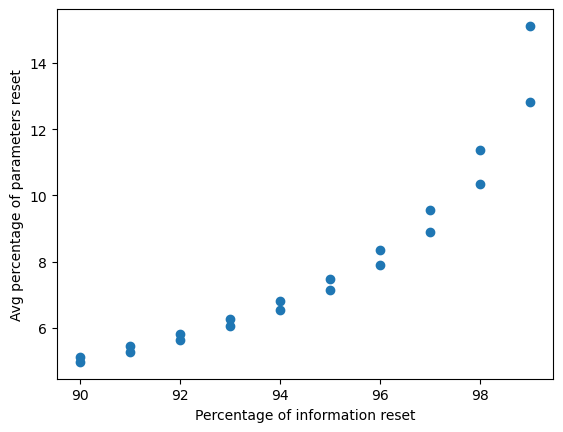

In [61]:
# Compute avg number of reset parameters percentage
avg_reset_parameters = [np.mean([test_result['reset_params_percentage'] for test_result in subtest_result]) for subtest_result in subtest_results]
plt.scatter(unlearning_percentages, avg_reset_parameters)
plt.xlabel("Percentage of information reset")
plt.ylabel("Avg percentage of parameters reset")


In [62]:
def compute_metrics(res, model_key):
    model_test_acc = res[model_key + '_clean_backdoor_accuracy']
    model_target_acc = res[model_key + '_poisoned_backdoor_accuracy']

    benchmark_test_acc = res['benchmark_clean_backdoor_accuracy']
    benchmark_target_acc = res['benchmark_poisoned_backdoor_accuracy']

    trained_test_acc = res['trained_clean_backdoor_accuracy']
    trained_target_acc = res['trained_poisoned_backdoor_accuracy']

    nta = model_test_acc / benchmark_test_acc
    nfs = (model_target_acc - trained_target_acc) / (benchmark_target_acc - trained_target_acc) if benchmark_target_acc != trained_target_acc else 0

    res[model_key + '_nta'] = nta
    res[model_key + '_nfs'] = nfs

for subtest_result in subtest_results:
    for test_result in subtest_result:
        compute_metrics(test_result, 'retrained')
        compute_metrics(test_result, 'reset')
        compute_metrics(test_result, 'random_retrained')
        compute_metrics(test_result, 'random_reset')

In [63]:
def compute_avg_std(subtest_results, key):
    avg = []
    std = []
    for subtest_result in subtest_results:
        values = [test_result[key] for test_result in subtest_result]
        avg.append(np.mean(values))
        std.append(np.std(values))
    return avg, std

# Compute NFS (Normalized Forgetting Score)
reset_nfs_avg, reset_nfs_std = compute_avg_std(subtest_results, 'reset_nfs')
retrained_nfs_avg, retrained_nfs_std = compute_avg_std(subtest_results, 'retrained_nfs')
random_reset_nfs_avg, random_reset_nfs_std = compute_avg_std(subtest_results, 'random_reset_nfs')
random_retrained_nfs_avg, random_retrained_nfs_std = compute_avg_std(subtest_results, 'random_retrained_nfs')

# Compute NFS_MIA (Normalized Forgetting Score based on MIA)
try:
    reset_nfs_mia_avg, reset_nfs_mia_std = compute_avg_std(subtest_results, 'reset_nfs_mia')
    retrained_nfs_mia_avg, retrained_nfs_mia_std = compute_avg_std(subtest_results, 'retrained_nfs_mia')
    random_reset_nfs_mia_avg, random_reset_nfs_mia_std = compute_avg_std(subtest_results, 'random_reset_nfs_mia')
    random_retrained_nfs_mia_avg, random_retrained_nfs_mia_std = compute_avg_std(subtest_results, 'random_retrained_nfs_mia')
except:
    reset_nfs_mia_avg, reset_nfs_mia_std = None, None
    retrained_nfs_mia_avg, retrained_nfs_mia_std = None, None
    random_reset_nfs_mia_avg, random_reset_nfs_mia_std = None, None
    random_retrained_nfs_mia_avg, random_retrained_nfs_mia_std = None, None

# Compute NTA (Normalized Test Accuracy)
reset_nta_avg, reset_nta_std = compute_avg_std(subtest_results, 'reset_nta')
retrained_nta_avg, retrained_nta_std = compute_avg_std(subtest_results, 'retrained_nta')
random_reset_nta_avg, random_reset_nta_std = compute_avg_std(subtest_results, 'random_reset_nta')
random_retrained_nta_avg, random_retrained_nta_std = compute_avg_std(subtest_results, 'random_retrained_nta')

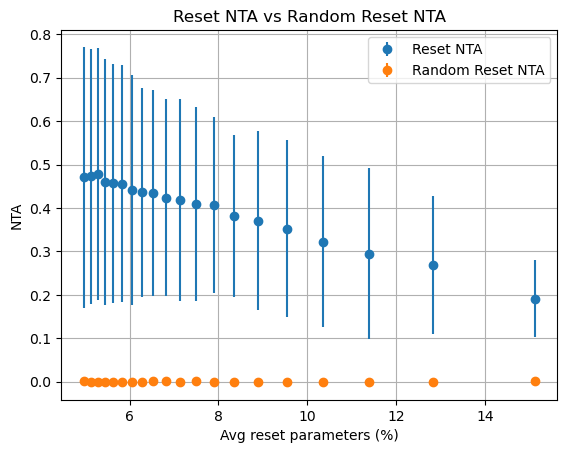

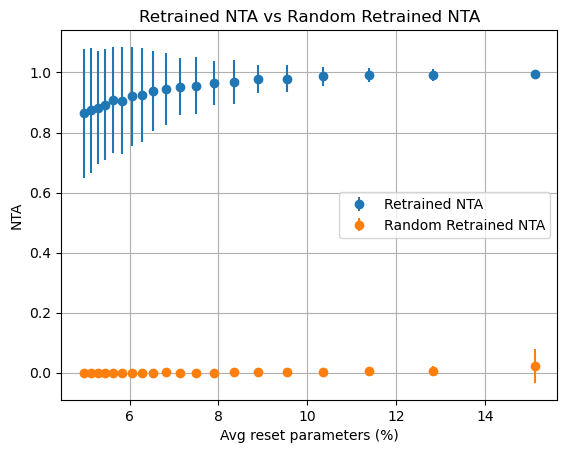

In [64]:
plt.errorbar(avg_reset_parameters, reset_nta_avg, yerr=reset_nta_std, label='Reset NTA', marker='o', linestyle='None')
plt.errorbar(avg_reset_parameters, random_reset_nta_avg, yerr=random_reset_nta_std, label='Random Reset NTA', marker='o', linestyle='None')
plt.title("Reset NTA vs Random Reset NTA")
plt.xlabel("Avg reset parameters (%)")
plt.ylabel("NTA")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(avg_reset_parameters, retrained_nta_avg, yerr=retrained_nta_std, label='Retrained NTA', marker='o', linestyle='None')
plt.errorbar(avg_reset_parameters, random_retrained_nta_avg, yerr=random_retrained_nta_std, label='Random Retrained NTA', marker='o', linestyle='None')
plt.title("Retrained NTA vs Random Retrained NTA")
plt.xlabel("Avg reset parameters (%)")
plt.ylabel("NTA")
plt.legend()
plt.grid()
plt.show()


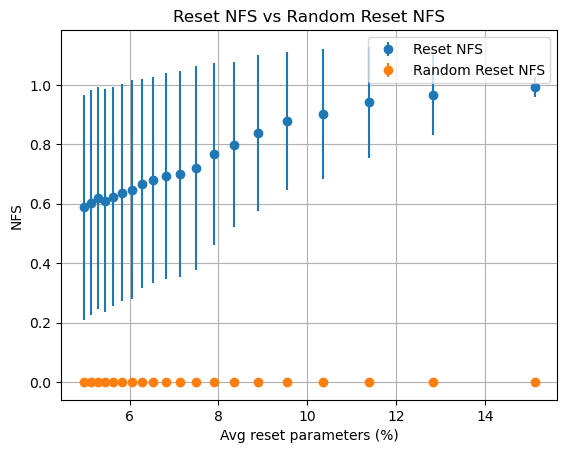

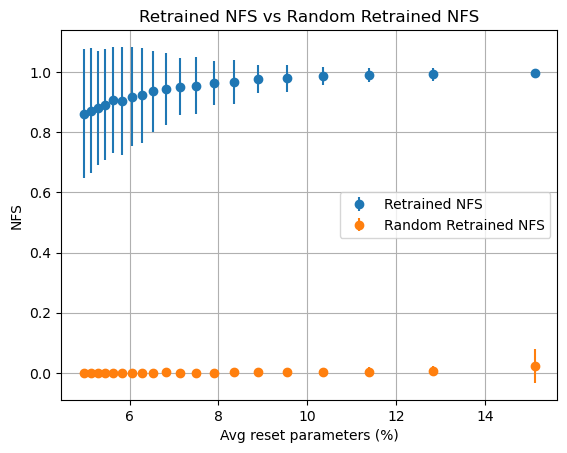

In [65]:
plt.errorbar(avg_reset_parameters, reset_nfs_avg, yerr=reset_nfs_std, label='Reset NFS', marker='o', linestyle='None')
plt.errorbar(avg_reset_parameters, random_reset_nfs_avg, yerr=random_reset_nfs_std, label='Random Reset NFS', marker='o', linestyle='None')
plt.title("Reset NFS vs Random Reset NFS")
plt.xlabel("Avg reset parameters (%)")
plt.ylabel("NFS")
plt.legend()
plt.grid()
plt.show()


plt.errorbar(avg_reset_parameters, retrained_nfs_avg, yerr=retrained_nfs_std, label='Retrained NFS', marker='o', linestyle='None')
plt.errorbar(avg_reset_parameters, random_retrained_nfs_avg, yerr=random_retrained_nfs_std, label='Random Retrained NFS', marker='o', linestyle='None')
plt.title("Retrained NFS vs Random Retrained NFS")
plt.xlabel("Avg reset parameters (%)")
plt.ylabel("NFS")
plt.legend()
plt.grid()
plt.show()


In [66]:
# Find best reset for each test
best_reset_idxs = []
best_retrained_idxs = []
for i in range(num_tests):
    reset_nta = [subtest_results[j][i]['reset_nta'] for j in range(len(subtest_results))]
    reset_nfs = [subtest_results[j][i]['reset_nfs'] for j in range(len(subtest_results))]
    retrained_nta = [subtest_results[j][i]['retrained_nta'] for j in range(len(subtest_results))]
    retrained_nfs = [subtest_results[j][i]['retrained_nfs'] for j in range(len(subtest_results))]
    best_reset_idx = np.argmin([np.sqrt((1 - nfs)**2 + (1 - nta)**2) for nfs, nta in zip(reset_nfs, reset_nta)])
    best_retrained_idx = np.argmin([np.sqrt((1 - nfs)**2 + (1 - nta)**2) for nfs, nta in zip(retrained_nfs, retrained_nta)])
    best_reset_idxs.append(best_reset_idx)
    best_retrained_idxs.append(best_retrained_idx)

In [67]:
plots_folder = "plots"
if not os.path.exists(plots_folder):
    os.makedirs(plots_folder)

dataset_name = init_params['dataset_name']
distribution_type = init_params['distribution_type']

save_path_pref = os.path.join(plots_folder, f"{dataset_name}_{distribution_type}")

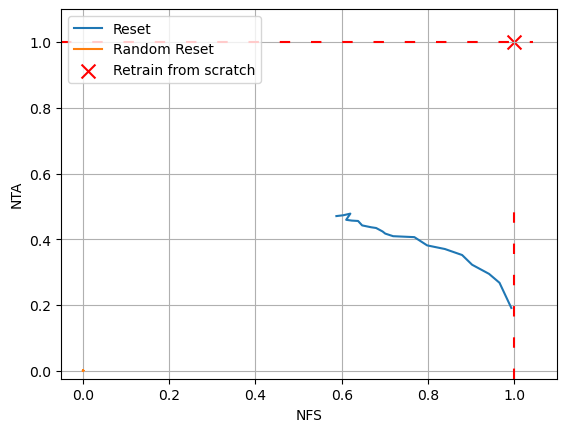

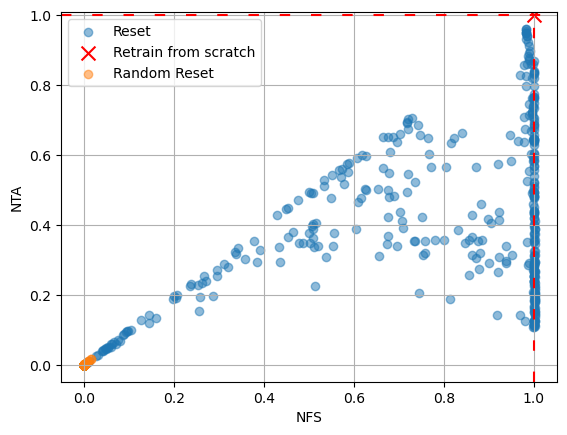

In [68]:
plt.plot(reset_nfs_avg, reset_nta_avg, label='Reset', marker='')
plt.plot(random_reset_nfs_avg, random_reset_nta_avg, label='Random Reset', marker='')

xlim = plt.xlim()
ylim = plt.ylim()
plt.scatter([1], [1], label='Retrain from scratch', color='red', marker='x', s=100)
plt.hlines(1, xlim[0], xlim[1], colors='red', linestyles=(0, (5, 10)))
plt.vlines(1, ylim[0], ylim[1], colors='red', linestyles=(0, (5, 10)))
plt.xlim(xlim)
plt.ylim(ylim)

plt.xlim(right=1.1)
plt.ylim(top=1.1)

plt.xlabel("NFS")
plt.ylabel("NTA")
plt.legend()
plt.grid()
plt.savefig(save_path_pref + "_NFS_vs_NTA_reset.png")
plt.show()

#scatter plot all points
reset_nfs = []
reset_nta = []
random_reset_nfs = []
random_reset_nta = []
for test_result in subtest_results:
    for result in test_result:
        reset_nfs.append(result['reset_nfs'])
        reset_nta.append(result['reset_nta'])
        random_reset_nfs.append(result['random_reset_nfs'])
        random_reset_nta.append(result['random_reset_nta'])

plt.scatter(reset_nfs, reset_nta, label='Reset', alpha=0.5)
xlim = plt.xlim()
ylim = plt.ylim()
plt.scatter([1], [1], label='Retrain from scratch', color='red', marker='x', s=100)
plt.hlines(1, xlim[0], xlim[1], colors='red', linestyles=(0, (5, 10)))
plt.vlines(1, ylim[0], ylim[1], colors='red', linestyles=(0, (5, 10)))
plt.xlim(xlim)
plt.ylim(ylim)
plt.scatter(random_reset_nfs, random_reset_nta, label='Random Reset', alpha=0.5)
plt.xlabel('NFS')
plt.ylabel("NTA")
plt.legend()
plt.grid()


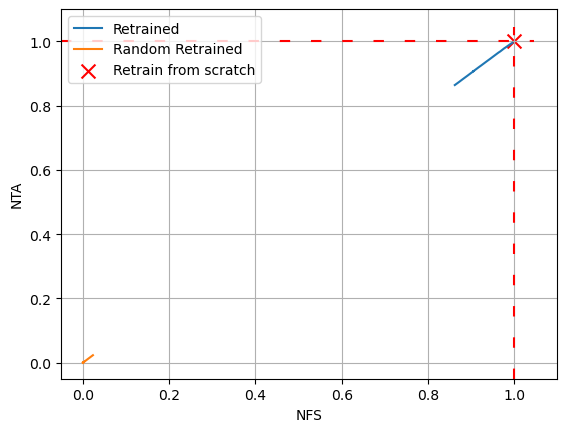

In [69]:
#retrained and random retrained NTA vs NFS
plt.plot(retrained_nfs_avg, retrained_nta_avg, label='Retrained', marker='')
plt.plot(random_retrained_nfs_avg, random_retrained_nta_avg, label='Random Retrained', marker='')

xlim = plt.xlim()
ylim = plt.ylim()
plt.scatter([1], [1], label='Retrain from scratch', color='red', marker='x', s=100)
plt.hlines(1, xlim[0], xlim[1], colors='red', linestyles=(0, (5, 10)))
plt.vlines(1, ylim[0], ylim[1], colors='red', linestyles=(0, (5, 10)))
plt.xlim(xlim)
plt.ylim(ylim)

plt.xlim(right=1.1)
plt.ylim(top=1.1)

plt.xlabel("NFS")
plt.ylabel("NTA")
plt.legend()
plt.grid()
plt.savefig(save_path_pref + "_NFS_vs_NTA_reset.png")
plt.show()


In [70]:
latex_dist : dict = {
    "random": "Random",
    "dirichlet": "Dirichlet",
    "preferential_class": "Preferential"
}

latex_datasets : dict = {
    "cifar10": "CIFAR-10",
    "FashionMNIST": "FMNIST",
    "mnist": "MNIST"
}

prefix = f"{latex_datasets[dataset_name]} & {latex_dist[distribution_type]} &"

BEST ALPHA NTA
MNIST & Random & $0.01 \pm 0.02$ & $99.14 \pm 0.16$ & $57.41 \pm 21.33$ & $0.58 \pm 0.22$ \\
BEST ALPHA NFS
MNIST & Random & $99.99 \pm 0.02$ & $0.11 \pm 0.08$ & $10.14 \pm 10.35$ & $0.90 \pm 0.10$ \\
BEST RESET
MNIST & Random & $93.85 \pm 3.41$ & $7.02 \pm 2.94$ \\


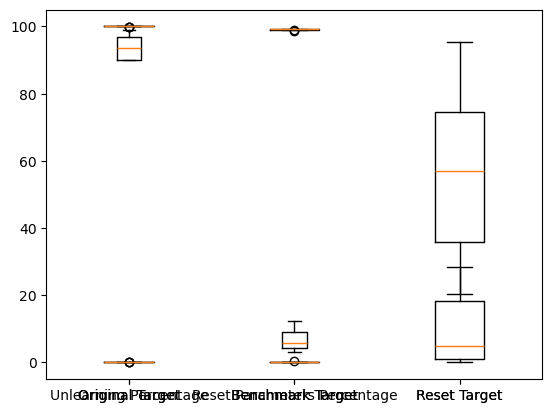

In [71]:
nta_s = [subtest_results[best_reset_idxs[i]][i]['reset_nta'] for i in range(num_tests)]
original_test_accuracies = [subtest_results[best_reset_idxs[i]][i]['trained_clean_backdoor_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
benchmark_test_accuracies = [subtest_results[best_reset_idxs[i]][i]['benchmark_clean_backdoor_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
reset_test_accuracies = [subtest_results[best_reset_idxs[i]][i]['reset_clean_backdoor_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]

plt.boxplot([original_test_accuracies, benchmark_test_accuracies, reset_test_accuracies], tick_labels=['Original Target', 'Benchmark Target', 'Reset Target'])
#plt.show()

print("BEST ALPHA NTA")
print(f"{prefix} ${np.mean(original_test_accuracies):.2f} \\pm {np.std(original_test_accuracies):.2f}$ & ${np.mean(benchmark_test_accuracies):.2f} \\pm {np.std(benchmark_test_accuracies):.2f}$ & ${np.mean(reset_test_accuracies):.2f} \\pm {np.std(reset_test_accuracies):.2f}$ & ${np.mean(nta_s):.2f} \\pm {np.std(nta_s):.2f}$ \\\\")

nfs_s = [subtest_results[best_reset_idxs[i]][i]['reset_nfs'] for i in range(num_tests)]
original_target_accuracies = [subtest_results[best_reset_idxs[i]][i]['trained_poisoned_backdoor_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
benchmark_target_accuracies = [subtest_results[best_reset_idxs[i]][i]['benchmark_poisoned_backdoor_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
reset_target_accuracies = [subtest_results[best_reset_idxs[i]][i]['reset_poisoned_backdoor_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]

plt.boxplot([original_target_accuracies, benchmark_target_accuracies, reset_target_accuracies], tick_labels=['Original Target', 'Benchmark Target', 'Reset Target'])
#plt.show()

print("BEST ALPHA NFS")
print(f"{prefix} ${np.mean(original_target_accuracies):.2f} \\pm {np.std(original_target_accuracies):.2f}$ & ${np.mean(benchmark_target_accuracies):.2f} \\pm {np.std(benchmark_target_accuracies):.2f}$ & ${np.mean(reset_target_accuracies):.2f} \\pm {np.std(reset_target_accuracies):.2f}$ & ${np.mean(nfs_s):.2f} \\pm {np.std(nfs_s):.2f}$ \\\\")

alphas = [unlearning_percentages[best_reset_idxs[i]] for i in range(num_tests)]
reset_param_percentages = [subtest_results[best_reset_idxs[i]][i]['reset_params_percentage'] for i in range(num_tests)]

plt.boxplot([alphas, reset_param_percentages], tick_labels=['Unlearning Percentage', 'Reset Parameters Percentage'])
#plt.show()

print("BEST RESET")
print(f"{prefix} ${np.mean(alphas):.2f} \\pm {np.std(alphas):.2f}$ & ${np.mean(reset_param_percentages):.2f} \\pm {np.std(reset_param_percentages):.2f}$ \\\\")


BEST ALPHA NTA
MNIST & Random & $0.01 \pm 0.02$ & $99.14 \pm 0.16$ & $98.77 \pm 1.06$ & $1.00 \pm 0.01$ \\
BEST ALPHA NFS
MNIST & Random & $99.99 \pm 0.02$ & $0.11 \pm 0.08$ & $0.52 \pm 1.06$ & $1.00 \pm 0.01$ \\
BEST retrained
MNIST & Random & $98.15 \pm 1.28$ & $11.87 \pm 3.72$ \\


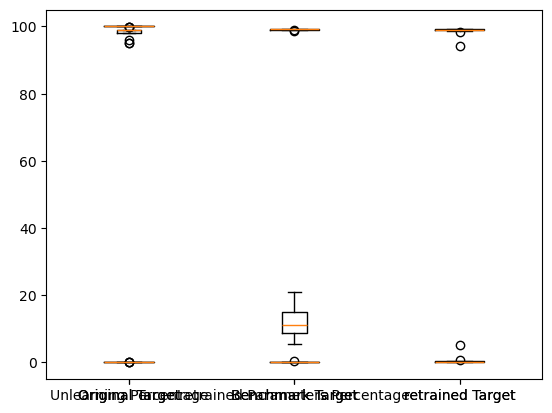

In [72]:
nta_s = [subtest_results[best_retrained_idxs[i]][i]['retrained_nta'] for i in range(num_tests)]
original_test_accuracies = [subtest_results[best_retrained_idxs[i]][i]['trained_clean_backdoor_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
benchmark_test_accuracies = [subtest_results[best_retrained_idxs[i]][i]['benchmark_clean_backdoor_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
retrained_test_accuracies = [subtest_results[best_retrained_idxs[i]][i]['retrained_clean_backdoor_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]

plt.boxplot([original_test_accuracies, benchmark_test_accuracies, retrained_test_accuracies], tick_labels=['Original Target', 'Benchmark Target', 'retrained Target'])
#plt.show()

print("BEST ALPHA NTA")
print(f"{prefix} ${np.mean(original_test_accuracies):.2f} \\pm {np.std(original_test_accuracies):.2f}$ & ${np.mean(benchmark_test_accuracies):.2f} \\pm {np.std(benchmark_test_accuracies):.2f}$ & ${np.mean(retrained_test_accuracies):.2f} \\pm {np.std(retrained_test_accuracies):.2f}$ & ${np.mean(nta_s):.2f} \\pm {np.std(nta_s):.2f}$ \\\\")

nfs_s = [subtest_results[best_retrained_idxs[i]][i]['retrained_nfs'] for i in range(num_tests)]
original_target_accuracies = [subtest_results[best_retrained_idxs[i]][i]['trained_poisoned_backdoor_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
benchmark_target_accuracies = [subtest_results[best_retrained_idxs[i]][i]['benchmark_poisoned_backdoor_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
retrained_target_accuracies = [subtest_results[best_retrained_idxs[i]][i]['retrained_poisoned_backdoor_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]

plt.boxplot([original_target_accuracies, benchmark_target_accuracies, retrained_target_accuracies], tick_labels=['Original Target', 'Benchmark Target', 'retrained Target'])
#plt.show()

print("BEST ALPHA NFS")
print(f"{prefix} ${np.mean(original_target_accuracies):.2f} \\pm {np.std(original_target_accuracies):.2f}$ & ${np.mean(benchmark_target_accuracies):.2f} \\pm {np.std(benchmark_target_accuracies):.2f}$ & ${np.mean(retrained_target_accuracies):.2f} \\pm {np.std(retrained_target_accuracies):.2f}$ & ${np.mean(nfs_s):.2f} \\pm {np.std(nfs_s):.2f}$ \\\\")

alphas = [unlearning_percentages[best_retrained_idxs[i]] for i in range(num_tests)]
retrained_param_percentages = [subtest_results[best_retrained_idxs[i]][i]['reset_params_percentage'] for i in range(num_tests)]

plt.boxplot([alphas, retrained_param_percentages], tick_labels=['Unlearning Percentage', 'retrained Parameters Percentage'])
#plt.show()

print("BEST retrained")
print(f"{prefix} ${np.mean(alphas):.2f} \\pm {np.std(alphas):.2f}$ & ${np.mean(retrained_param_percentages):.2f} \\pm {np.std(retrained_param_percentages):.2f}$ \\\\")


In [73]:
from datetime import datetime
start_retrain_str = "15:28:36,006"
stop_retrain_str = "15:41:34,678"
start_reset_str = "15:41:34,678"
stop_reset_str = "15:45:24,672"
start_retrain = datetime.strptime(start_retrain_str, "%H:%M:%S,%f")
stop_retrain = datetime.strptime(stop_retrain_str, "%H:%M:%S,%f")
start_reset = datetime.strptime(start_reset_str, "%H:%M:%S,%f")
stop_reset = datetime.strptime(stop_reset_str, "%H:%M:%S,%f")
retrain_time = (stop_retrain - start_retrain).total_seconds()
reset_time = (stop_reset - start_reset).total_seconds()
print(f"${int(retrain_time)}$ & ${int(reset_time)}$ & ${(reset_time/retrain_time):.2f}$\\\\")

$778$ & $229$ & $0.30$\\
